In [1]:
from format_conversion import ply_to_np
from visualize import visualize
from trainer import learn_pdf

import matplotlib.pyplot as plt
import numpy as np
import torch

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
arr = ply_to_np('datasets/bed_0516.ply')
arr.shape

(20000, 3)

In [ ]:
from flow_models import learn_1d_pdf
pdf = learn_1d_pdf(arr[:, 0])
pdf

(<scipy.stats._kde.gaussian_kde at 0x7defa2105710>,
 <function flow_models.learn_1d_pdf.<locals>.<lambda>(x)>,
 np.float64(0.01))

In [14]:
from torchkde import KernelDensity
import torch

kde = KernelDensity(bandwidth=1.0, kernel='gaussian') # create kde object with isotropic bandwidth matrix
_ = kde.fit(torch.from_numpy(arr[:, 0:1]).float())
wow = kde.score_samples(torch.linspace(arr[:, 0].min(), arr[:, 0].max(), 1000, device='cpu').reshape(-1, 1))

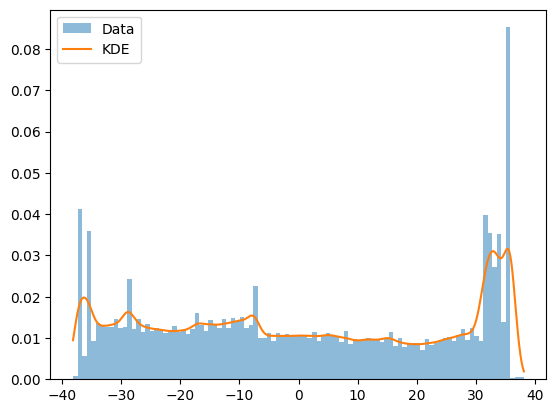

In [17]:
_ = plt.hist(arr[:, 0], bins=100, density=True, alpha=0.5, label='Data')
x = np.linspace(arr[:, 0].min(), arr[:, 0].max(), 1000)
plt.plot(x, wow.exp(), label='KDE')
plt.legend()

In [ ]:
f = learn_pdf(
    torch.tensor(arr[:, 0:1], dtype=torch.float32),
    model='RealNVP',
    epochs=100,
    batch_size=20_000,
    device='cuda:0'
)